In [1]:
# import packages
import nltk
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from transformers import BertTokenizer

c:\Users\ljuny\Downloads\music\bin\conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preprocess text data

title_cleaned and text_cleaned for typical ML models (e.g. logistic regression, svm)

do NOT use for BERT models - BERT models will work better with tokenized data and encodings that would be too large to store (BertTokenizer)

if want to use BERT, copy and paste the bottom cell of this section when training the model

In [2]:
df = pd.read_csv("WELFake_Dataset.csv")
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [3]:
df.shape

(72134, 4)

In [4]:
# drop the index column carried over from the original csv
df = df.drop(columns=["Unnamed: 0"])

# drop rows where title or text is null
df = df.dropna(subset=["title", "text"])

# drop rows where text is whitespace-only (744 rows with no usable content)
df = df[df["text"].str.strip() != ""]

# drop duplicate (title, text) pairs â€” the original drop_duplicates() on all columns
# was a no-op because the old index column made every row unique
df = df.drop_duplicates(subset=["title", "text"])

df = df.reset_index(drop=True)
df.shape

(62592, 3)

In [5]:
def clean_text(text):
    """Lowercase, strip HTML tags, remove URLs, and remove digits."""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)       # strip HTML tags
    text = re.sub(r"https?://\S+", " ", text)   # remove URLs
    text = re.sub(r"[0-9]+", "", text)           # remove digits
    return text

df["title_cleaned"] = df["title"].apply(clean_text)
df["text_cleaned"] = df["text"].apply(clean_text)

df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement on high alert following threat...,no comment is expected from barack obama membe...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable! obama’s attorney general says mo...,"now, most of the demonstrators gathered last ..."
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"bobby jindal, raised hindu, uses story of chri...",a dozen politically active pastors came here f...
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan : russia unvelis an image of its terrify...,"the rs- sarmat missile, dubbed satan , will re..."
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,about time! christian group sues amazon and sp...,all we can say on this one is it s about time ...


In [6]:
# tokenize
df["title_cleaned"] = df["title_cleaned"].apply(word_tokenize)
df["text_cleaned"] = df["text_cleaned"].apply(word_tokenize)
df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, on, high, alert, following,...","[no, comment, is, expected, from, barack, obam..."
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, !, obama, ’, s, attorney, gener...","[now, ,, most, of, the, demonstrators, gathere..."
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, ,, raised, hindu, ,, uses, sto...","[a, dozen, politically, active, pastors, came,..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, :, russia, unvelis, an, image, of, its...","[the, rs-, sarmat, missile, ,, dubbed, satan, ..."
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[about, time, !, christian, group, sues, amazo...","[all, we, can, say, on, this, one, is, it, s, ..."


In [7]:
# keep only alphabetic tokens
alpha_re = re.compile(r"^[a-z]+$")

df["title_cleaned"] = df["title_cleaned"].apply(lambda tokens: [w for w in tokens if alpha_re.match(w)])
df["text_cleaned"] = df["text_cleaned"].apply(lambda tokens: [w for w in tokens if alpha_re.match(w)])
df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, on, high, alert, following,...","[no, comment, is, expected, from, barack, obam..."
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, obama, s, attorney, general, sa...","[now, most, of, the, demonstrators, gathered, ..."
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, raised, hindu, uses, story, of...","[a, dozen, politically, active, pastors, came,..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, russia, unvelis, an, image, of, its, t...","[the, sarmat, missile, dubbed, satan, will, re..."
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[about, time, christian, group, sues, amazon, ...","[all, we, can, say, on, this, one, is, it, s, ..."


In [8]:
# remove stopwords
stop_list = set(stopwords.words("english"))

df["title_cleaned"] = df["title_cleaned"].apply(lambda tokens: [w for w in tokens if w not in stop_list])
df["text_cleaned"] = df["text_cleaned"].apply(lambda tokens: [w for w in tokens if w not in stop_list])

df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, high, alert, following, thr...","[comment, expected, barack, obama, members, fy..."
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, obama, attorney, general, says,...","[demonstrators, gathered, last, night, exercis..."
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, raised, hindu, uses, story, ch...","[dozen, politically, active, pastors, came, pr..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, russia, unvelis, image, terrifying, ne...","[sarmat, missile, dubbed, satan, replace, flie..."
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[time, christian, group, sues, amazon, splc, d...","[say, one, time, someone, sued, southern, pove..."


In [9]:
# lemmatization
lemmatizer = WordNetLemmatizer()

df["title_cleaned"] = df["title_cleaned"].apply(lambda tokens: [lemmatizer.lemmatize(w) for w in tokens])
df["text_cleaned"] = df["text_cleaned"].apply(lambda tokens: [lemmatizer.lemmatize(w) for w in tokens])

df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, high, alert, following, thr...","[comment, expected, barack, obama, member, fyf..."
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, obama, attorney, general, say, ...","[demonstrator, gathered, last, night, exercisi..."
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, raised, hindu, us, story, chri...","[dozen, politically, active, pastor, came, pri..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, russia, unvelis, image, terrifying, ne...","[sarmat, missile, dubbed, satan, replace, fly,..."
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[time, christian, group, sue, amazon, splc, de...","[say, one, time, someone, sued, southern, pove..."


In [10]:
df.to_csv("text_data.csv", index=False)

In [11]:
tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

encoding = tokenizer(
    df["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

## Preprocess Image data

CASIA 2.0 dataset — Au (Authentic) vs Tp (Tampered) images.

Images have mixed sizes (256-800px) and formats (jpg, bmp, tif). The pipeline below resizes them to a uniform 224x224, normalizes pixel values to [0, 1], and applies data augmentation.

The processed dataset will take up a lot of space so copy and paste the code below when training the model.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# load images — Au and Tp folders are used as class labels
# Au = Authentic (label 0), Tp = Tampered (label 1)
train_ds = tf.keras.utils.image_dataset_from_directory(
    ".",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    class_names=["Au", "Tp"]
)

print(train_ds.class_names)

Found 9555 files belonging to 2 classes.
['Au', 'Tp']


In [3]:
# normalize pixel values from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

In [4]:
# verify image shapes and pixel range after normalization
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Min pixel value: 0.0
Max pixel value: 1.0


In [5]:
# data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

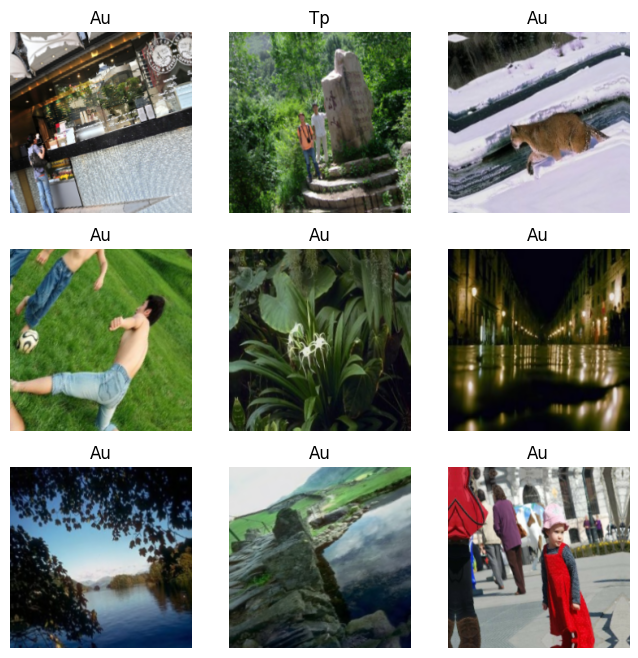

In [7]:
# preview a batch of augmented images
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title("Au" if int(labels[i][0]) == 0 else "Tp")
        plt.axis("off")
    plt.show()